In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
gtfs_path = Path("../data/raw/gtfs")

In [7]:
stops_file = gtfs_path / "stops.txt"

print(stops_file)

..\data\raw\gtfs\stops.txt


In [8]:
stops = pd.read_csv(stops_file)

In [9]:
stops.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,platform_code
0,1000,1000.0,Frederick Station (Frederick / King),NaN,43.449674,-80.487209,NaN,https://www.grt.ca/en/schedules-maps/platform-...,0,NaN,1.0,NaN
1,1001,1001.0,Frederick / Region Of Waterloo Headquarters,NaN,43.452334,-80.484195,NaN,NaN,0,NaN,1.0,NaN
2,1002,1002.0,Frederick / Otto,NaN,43.453004,-80.482917,NaN,NaN,0,NaN,1.0,NaN
3,1003,1003.0,Frederick / Samuel,NaN,43.454834,-80.479514,NaN,NaN,0,NaN,1.0,NaN
4,1004,1004.0,Frederick / Merner,NaN,43.456218,-80.476907,NaN,NaN,0,NaN,1.0,NaN


In [10]:
stops.shape

(2260, 12)

In [11]:
for column in stops.columns:
    print(column)

stop_id
stop_code
stop_name
stop_desc
stop_lat
stop_lon
zone_id
stop_url
location_type
parent_station
wheelchair_boarding
platform_code


In [12]:
stops.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260 entries, 0 to 2259
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              2260 non-null   str    
 1   stop_code            2246 non-null   float64
 2   stop_name            2260 non-null   str    
 3   stop_desc            0 non-null      float64
 4   stop_lat             2260 non-null   float64
 5   stop_lon             2260 non-null   float64
 6   zone_id              0 non-null      float64
 7   stop_url             103 non-null    str    
 8   location_type        2260 non-null   int64  
 9   parent_station       69 non-null     str    
 10  wheelchair_boarding  2246 non-null   float64
 11  platform_code        14 non-null     float64
dtypes: float64(7), int64(1), str(4)
memory usage: 212.0 KB


In [13]:
stops["location_type"].value_counts().sort_index()

location_type
0    2246
1      14
Name: count, dtype: int64

In [14]:
stops["parent_station"].notna().sum()

np.int64(69)

In [15]:
stops[
    ["stop_id", "stop_name", "stop_lat", "stop_lon", "location_type", "parent_station"]
].head(10)

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,1000,Frederick Station (Frederick / King),43.449674,-80.487209,0,NaN
1,1001,Frederick / Region Of Waterloo Headquarters,43.452334,-80.484195,0,NaN
2,1002,Frederick / Otto,43.453004,-80.482917,0,NaN
3,1003,Frederick / Samuel,43.454834,-80.479514,0,NaN
4,1004,Frederick / Merner,43.456218,-80.476907,0,NaN
5,1006,Frederick / Frederick Mall,43.457932,-80.473579,0,NaN
6,1011,Franklin / Lindsay,43.396313,-80.303914,0,NaN
7,1012,River / Manchester,43.458471,-80.454180,0,NaN
8,1013,River / Lorraine,43.457265,-80.449484,0,NaN
9,1014,River / Hickson,43.454293,-80.446678,0,NaN


In [16]:
stops[
    ["stop_id", "stop_name", "stop_lat", "stop_lon"]
].isna().sum()

stop_id      0
stop_name    0
stop_lat     0
stop_lon     0
dtype: int64

In [17]:
stops["stop_id"].duplicated().sum()

np.int64(0)

In [18]:
stops["location_type"].value_counts().sort_index()

location_type
0    2246
1      14
Name: count, dtype: int64

In [19]:
transit_stops = stops[
    stops["location_type"] == 0
].copy()

In [20]:
transit_stops.shape

(2246, 12)

In [21]:
transit_stops["location_type"].value_counts()

location_type
0    2246
Name: count, dtype: int64

In [22]:
type(transit_stops)

pandas.DataFrame

In [23]:
stops_gdf = gpd.GeoDataFrame(
    transit_stops,
    geometry=gpd.points_from_xy(
        transit_stops["stop_lon"],
        transit_stops["stop_lat"]
    ),
    crs="EPSG:4326"
)

In [24]:
type(stops_gdf)

geopandas.geodataframe.GeoDataFrame

In [25]:
stops_gdf[
    ["stop_id", "stop_name", "stop_lat", "stop_lon", "geometry"]
].head(10)

,stop_id,stop_name,stop_lat,stop_lon,geometry
0,1000,Frederick Station (Frederick / King),43.449674,-80.487209,POINT (-80.48721 43.44967)
1,1001,Frederick / Region Of Waterloo Headquarters,43.452334,-80.484195,POINT (-80.4842 43.45233)
2,1002,Frederick / Otto,43.453004,-80.482917,POINT (-80.48292 43.453)
3,1003,Frederick / Samuel,43.454834,-80.479514,POINT (-80.47951 43.45483)
4,1004,Frederick / Merner,43.456218,-80.476907,POINT (-80.47691 43.45622)
5,1006,Frederick / Frederick Mall,43.457932,-80.473579,POINT (-80.47358 43.45793)
6,1011,Franklin / Lindsay,43.396313,-80.303914,POINT (-80.30391 43.39631)
7,1012,River / Manchester,43.458471,-80.454180,POINT (-80.45418 43.45847)
8,1013,River / Lorraine,43.457265,-80.449484,POINT (-80.44948 43.45726)
9,1014,River / Hickson,43.454293,-80.446678,POINT (-80.44668 43.45429)


In [26]:
stops_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
stops_gdf.geometry.geom_type.value_counts()

Point    2246
Name: count, dtype: int64

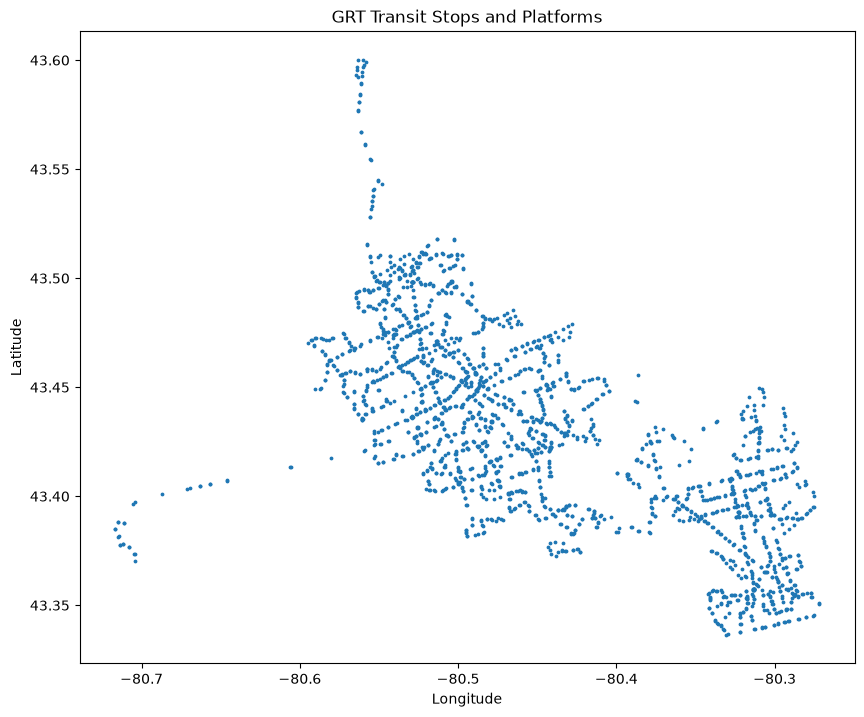

In [28]:
stops_gdf.plot(
    figsize=(10, 10),
    markersize=3
)

plt.title("GRT Transit Stops and Platforms")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()